# NUVM Distribution: Step-by-Step Symbolic Derivation

This notebook derives the PDF and main properties of the Normal Uniform Variance Mixture (NUVM) model. It is designed for research writing: each mathematical property is introduced, displayed, derived symbolically, and then checked numerically.

Model assumption:

$$X\mid V=v \sim N(\mu,v), \qquad V\sim U((1-a)\sigma^2,(1+a)\sigma^2), \qquad 0<a<1.$$

In [2]:
import sys
print(sys.executable)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\python.exe


In [4]:
import sympy as sp

print(sp.__version__)
print("NUVM environment ready")

1.14.0
NUVM environment ready


## 1. Setup

In [1]:
import sympy as sp

sp.init_printing(use_latex='mathjax')

x, mu, v = sp.symbols('x mu v', real=True)
sigma, a = sp.symbols('sigma a', positive=True)

# The model also requires 0 < a < 1 so that L > 0.
L = (1 - a) * sigma**2
U = (1 + a) * sigma**2

display(sp.Eq(sp.Symbol('L'), L))
display(sp.Eq(sp.Symbol('U'), U))
display(sp.Eq(U - L, sp.simplify(U - L)))

     2        
L = σ ⋅(1 - a)

     2        
U = σ ⋅(a + 1)

   2            2                2
- σ ⋅(1 - a) + σ ⋅(a + 1) = 2⋅a⋅σ 

## 2. Conditional Density

Since $X\mid V=v$ is normal with mean $\mu$ and variance $v$,

$$f(x\mid v)=\frac{1}{\sqrt{2\pi v}}\exp\left[-\frac{(x-\mu)^2}{2v}\right].$$

In [2]:
f_x_given_v = 1 / sp.sqrt(2 * sp.pi * v) * sp.exp(-(x - mu)**2 / (2 * v))

display(sp.Eq(sp.Function('f')(x, v), f_x_given_v))

                       2 
              -(-μ + x)  
              ───────────
                  2⋅v    
          √2⋅ℯ           
f(x, v) = ───────────────
              2⋅√π⋅√v    

## 3. Mixing Density

The variance mixing variable is uniform on $[L,U]$, so

$$g(v)=\frac{1}{U-L}=\frac{1}{2a\sigma^2}, \qquad L\le v\le U.$$

In [3]:
g_v = sp.simplify(1 / (U - L))

display(sp.Eq(sp.Function('g')(v), 1 / (U - L)))
display(sp.Eq(sp.Function('g')(v), g_v))

                   1            
g(v) = ─────────────────────────
          2            2        
       - σ ⋅(1 - a) + σ ⋅(a + 1)

         1   
g(v) = ──────
            2
       2⋅a⋅σ 

## 4. Build the Marginal PDF

The marginal density is obtained by integrating out the random variance $V$:

$$f(x)=\int_L^U f(x\mid v)g(v)\,dv.$$

In [4]:
integrand = sp.simplify(f_x_given_v * g_v)
pdf_integral = sp.Integral(integrand, (v, L, U))

display(sp.Eq(sp.Function('f')(x), pdf_integral))
display(sp.Eq(sp.Symbol('integrand'), integrand))

        2                          
       σ ⋅(a + 1)                  
           ⌠                       
           ⎮                  2    
           ⎮          -(μ - x)     
           ⎮          ──────────   
           ⎮             2⋅v       
           ⎮      √2⋅ℯ             
f(x) =     ⎮      ────────────── dv
           ⎮               2       
           ⎮       4⋅√π⋅a⋅σ ⋅√v    
           ⌡                       
        2                          
       σ ⋅(1 - a)                  

                        2 
                -(μ - x)  
                ──────────
                   2⋅v    
            √2⋅ℯ          
integrand = ──────────────
                     2    
             4⋅√π⋅a⋅σ ⋅√v 

## 5. Symbolic PDF: Antiderivative Method

SymPy may or may not simplify the definite integral immediately. A reliable derivation uses the antiderivative

$$\int v^{-1/2}\exp\left[-\frac{(x-\mu)^2}{2v}\right]dv.$$

Let $z=x-\mu$. One antiderivative is

$$A(v)=2\sqrt{v}\exp\left(-\frac{z^2}{2v}\right)+\sqrt{2\pi}\,|z|\,\operatorname{erf}\left(\frac{|z|}{\sqrt{2v}}\right).$$

The next cell verifies this by differentiating $A(v)$.

In [5]:
z = x - mu
A = 2 * sp.sqrt(v) * sp.exp(-z**2 / (2 * v)) + sp.sqrt(2 * sp.pi) * sp.Abs(z) * sp.erf(sp.Abs(z) / sp.sqrt(2 * v))
target_integrand_without_constants = v**(-sp.Rational(1, 2)) * sp.exp(-z**2 / (2 * v))

display(sp.Eq(sp.Symbol('A_v'), A))
display(sp.Eq(sp.diff(A, v), sp.simplify(sp.diff(A, v))))
display(sp.Eq(sp.simplify(sp.diff(A, v) - target_integrand_without_constants), 0))

                    2                                 
           -(-μ + x)                                  
           ───────────                                
               2⋅v                        ⎛√2⋅│μ - x│⎞
Aᵥ = 2⋅√v⋅ℯ            + √2⋅√π⋅│μ - x│⋅erf⎜──────────⎟
                                          ⎝   2⋅√v   ⎠

          2                        2                      2             2 
 -(-μ + x)                -(-μ + x)               -(μ - x)      -(μ - x)  
 ───────────              ───────────             ──────────    ──────────
     2⋅v               2      2⋅v              2     2⋅v           2⋅v    
ℯ              (-μ + x) ⋅ℯ              (μ - x) ⋅ℯ             ℯ          
──────────── + ────────────────────── - ──────────────────── = ───────────
     √v                  3/2                     3/2               √v     
                        v                       v                         

True

Therefore,

$$f(x)=\frac{A(U)-A(L)}{(U-L)\sqrt{2\pi}}.$$

In [6]:
A_L = A.subs(v, L)
A_U = A.subs(v, U)
pdf_closed = sp.simplify((A_U - A_L) / ((U - L) * sp.sqrt(2 * sp.pi)))

display(sp.Eq(sp.Function('f')(x), (A_U - A_L) / ((U - L) * sp.sqrt(2 * sp.pi))))
display(sp.Eq(sp.Function('f')(x), pdf_closed))

          ⎛                          2                             2           ↪
          ⎜                 -(-μ + x)                     -(-μ + x)            ↪
          ⎜                 ────────────                  ────────────         ↪
          ⎜                    2                             2                 ↪
          ⎜        _______  2⋅σ ⋅(1 - a)         _______  2⋅σ ⋅(a + 1)         ↪
       √2⋅⎜- 2⋅σ⋅╲╱ 1 - a ⋅ℯ             + 2⋅σ⋅╲╱ a + 1 ⋅ℯ             - √2⋅√π ↪
          ⎜                                                                    ↪
          ⎝                                                                    ↪
f(x) = ─────────────────────────────────────────────────────────────────────── ↪
                                                               ⎛   2           ↪
                                                          2⋅√π⋅⎝- σ ⋅(1 - a) + ↪

↪                                                               ⎞
↪                                         

                                2                             2                ↪
                         (μ - x)                      -(μ - x)                 ↪
                       ─────────────                 ─────────────             ↪
                            2      2                      2      2   │μ - x│⋅e ↪
              _______  2⋅a⋅σ  - 2⋅σ         _______  2⋅a⋅σ  + 2⋅σ              ↪
         √2⋅╲╱ 1 - a ⋅ℯ                √2⋅╲╱ a + 1 ⋅ℯ                          ↪
f(x) = - ─────────────────────────── + ─────────────────────────── - ───────── ↪
                  2⋅√π⋅a⋅σ                      2⋅√π⋅a⋅σ                       ↪
                                                                               ↪

↪                                               
↪                                               
↪   ⎛ √2⋅│μ - x│  ⎞              ⎛ √2⋅│μ - x│  ⎞
↪ rf⎜─────────────⎟   │μ - x│⋅erf⎜─────────────⎟
↪   ⎜      _______⎟              ⎜      _______⎟
↪   ⎝2⋅σ⋅╲╱ 1 - a ⎠      

For comparison, ask SymPy to evaluate the original integral directly.

In [7]:
pdf_direct = sp.integrate(integrand, (v, L, U))

display(sp.Eq(sp.Function('f_direct')(x), pdf_direct))
display(sp.Eq(sp.simplify(pdf_direct - pdf_closed), 0))

                   ⎛                                                           ↪
                   ⎜                                                           ↪
                   ⎜                                                           ↪
                   ⎜                                                           ↪
                   ⎜           ⎛    √2⋅μ            √2⋅x     ⎞         _______ ↪
                √2⋅⎜√2⋅√π⋅μ⋅erf⎜───────────── - ─────────────⎟ + 2⋅σ⋅╲╱ 1 - a  ↪
                   ⎜           ⎜      _______         _______⎟                 ↪
                   ⎝           ⎝2⋅σ⋅╲╱ 1 - a    2⋅σ⋅╲╱ 1 - a ⎠                 ↪
f_direct(x) = - ────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪         2             2                                                      ↪
↪       -μ            -x   

       ⎛ √2⋅(μ - x)  ⎞        ⎛ √2⋅(μ - x)  ⎞        ⎛ √2⋅(μ - x)  ⎞        ⎛  ↪
- μ⋅erf⎜─────────────⎟ + μ⋅erf⎜─────────────⎟ + x⋅erf⎜─────────────⎟ - x⋅erf⎜─ ↪
       ⎜      _______⎟        ⎜      _______⎟        ⎜      _______⎟        ⎜  ↪
       ⎝2⋅σ⋅╲╱ 1 - a ⎠        ⎝2⋅σ⋅╲╱ a + 1 ⎠        ⎝2⋅σ⋅╲╱ 1 - a ⎠        ⎝2 ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                            2  ↪
                                                                       2⋅a⋅σ   ↪

↪ √2⋅(μ - x)  ⎞              ⎛ √2⋅│μ - x│  ⎞              ⎛ √2⋅│μ - x│  ⎞    
↪ ────────────⎟ + │μ - x│⋅erf⎜─────────────⎟ - │μ - x│⋅erf⎜─────────────⎟    
↪      _______⎟              ⎜      _______⎟              ⎜      _______⎟    
↪ ⋅σ⋅╲╱ a + 1 ⎠              ⎝2⋅σ⋅╲╱ 1 - a ⎠              ⎝2⋅σ⋅╲╱ a + 1 ⎠    
↪ ─────────────────────────────────────────────────────────────────────── = 0
↪                                         

## 6. Normalization Proof

Because $f(x\mid v)$ is a valid normal density for every $v>0$ and $g(v)$ is a valid uniform density, the marginal density integrates to one:

$$\int_{-\infty}^{\infty} f(x)\,dx=\int_L^U g(v)\left[\int_{-\infty}^{\infty}f(x\mid v)\,dx\right]dv=\int_L^U g(v)\,dv=1.$$

In [8]:
inner_normal_integral = sp.Integral(f_x_given_v, (x, -sp.oo, sp.oo))
normalization_step = sp.integrate(g_v, (v, L, U))

display(sp.Eq(inner_normal_integral, 1))
display(sp.Eq(sp.Integral(g_v, (v, L, U)), normalization_step))

∞                        
⌠                        
⎮               2        
⎮      -(-μ + x)         
⎮      ───────────       
⎮          2⋅v           
⎮  √2⋅ℯ                  
⎮  ─────────────── dx = 1
⎮      2⋅√π⋅√v           
⌡                        
-∞                       

 2                                    
σ ⋅(a + 1)                            
    ⌠                                 
    ⎮        1           1 - a   a + 1
    ⎮      ────── dv = - ───── + ─────
    ⎮           2         2⋅a     2⋅a 
    ⎮      2⋅a⋅σ                      
    ⌡                                 
 2                                    
σ ⋅(1 - a)                            

## 7. Mean Derivation

Use the law of total expectation:

$$E[X]=E(E[X\mid V]).$$

Since $X\mid V=v\sim N(\mu,v)$,

$$E[X\mid V]=\mu.$$

In [9]:
EX_given_V = mu
EX = sp.simplify(sp.integrate(EX_given_V * g_v, (v, L, U)))

display(sp.Eq(sp.Symbol('E_X_given_V'), EX_given_V))
display(sp.Eq(sp.Symbol('E_X'), sp.Integral(EX_given_V * g_v, (v, L, U))))
display(sp.Eq(sp.Symbol('E_X'), EX))

E_X_given_V = μ

       2                  
      σ ⋅(a + 1)          
          ⌠               
          ⎮        μ      
E_X =     ⎮      ────── dv
          ⎮           2   
          ⎮      2⋅a⋅σ    
          ⌡               
       2                  
      σ ⋅(1 - a)          

E_X = μ

## 8. Variance Derivation

Use the law of total variance:

$$\operatorname{Var}(X)=E[\operatorname{Var}(X\mid V)]+\operatorname{Var}(E[X\mid V]).$$

Here, $\operatorname{Var}(X\mid V)=V$ and $E[X\mid V]=\mu$, so the second term is zero.

In [10]:
EV = sp.simplify(sp.integrate(v * g_v, (v, L, U)))
Var_EX_given_V = 0
VarX = sp.simplify(EV + Var_EX_given_V)

display(sp.Eq(sp.Symbol('E_V'), sp.Integral(v * g_v, (v, L, U))))
display(sp.Eq(sp.Symbol('E_V'), EV))
display(sp.Eq(sp.Symbol('Var_E_X_given_V'), Var_EX_given_V))
display(sp.Eq(sp.Symbol('Var_X'), VarX))

       2                  
      σ ⋅(a + 1)          
          ⌠               
          ⎮        v      
E_V =     ⎮      ────── dv
          ⎮           2   
          ⎮      2⋅a⋅σ    
          ⌡               
       2                  
      σ ⋅(1 - a)          

       2
E_V = σ 

Var_E_X_given_V = 0

         2
Var_X = σ 

## 9. Fourth Central Moment

For a normal variable with variance $V$,

$$E[(X-\mu)^4\mid V]=3V^2.$$

In [11]:
moment4_conditional = 3 * v**2
moment4_integral = sp.Integral(moment4_conditional * g_v, (v, L, U))
moment4 = sp.simplify(sp.integrate(moment4_conditional * g_v, (v, L, U)))
moment4_expected_form = 3 * sigma**4 * (1 + a**2 / 3)

display(sp.Eq(sp.Symbol('E_central_4_given_V'), moment4_conditional))
display(sp.Eq(sp.Symbol('E_central_4'), moment4_integral))
display(sp.Eq(sp.Symbol('E_central_4'), moment4))
display(sp.Eq(moment4, sp.simplify(moment4_expected_form)))

                         2
E_central_4_given_V = 3⋅v 

               2                  
              σ ⋅(a + 1)          
                  ⌠               
                  ⎮          2    
                  ⎮       3⋅v     
E_central_4 =     ⎮      ────── dv
                  ⎮           2   
                  ⎮      2⋅a⋅σ    
                  ⌡               
               2                  
              σ ⋅(1 - a)          

               4 ⎛ 2    ⎞
E_central_4 = σ ⋅⎝a  + 3⎠

True

## 10. Kurtosis and Excess Kurtosis

The kurtosis is

$$\kappa=\frac{E[(X-\mu)^4]}{\operatorname{Var}(X)^2}.$$

In [12]:
kappa = sp.simplify(moment4 / VarX**2)
excess_kurtosis = sp.simplify(kappa - 3)

display(sp.Eq(sp.Symbol('kappa'), moment4 / VarX**2))
display(sp.Eq(sp.Symbol('kappa'), kappa))
display(sp.Eq(sp.Symbol('excess_kurtosis'), excess_kurtosis))

     2    
κ = a  + 3

     2    
κ = a  + 3

                  2
excessₖᵤᵣₜₒₛᵢₛ = a 

## 11. MGF and Characteristic Function

Conditional on $V$, the MGF and characteristic function are

$$M_{X\mid V}(t)=\exp\left(\mu t+\frac{Vt^2}{2}\right),$$

$$\phi_{X\mid V}(t)=\exp\left(i\mu t-\frac{Vt^2}{2}\right).$$

In [13]:
t = sp.symbols('t', real=True)
i = sp.I

MGF_conditional = sp.exp(mu * t + v * t**2 / 2)
CF_conditional = sp.exp(i * mu * t - v * t**2 / 2)

display(sp.Eq(sp.Symbol('M_X_given_V_t'), MGF_conditional))
display(sp.Eq(sp.Symbol('phi_X_given_V_t'), CF_conditional))

                        2  
                       t ⋅v
                 μ⋅t + ────
                        2  
M_X_given_V_t = ℯ          

                          2  
                         t ⋅v
                 ⅈ⋅μ⋅t - ────
                          2  
φ_X_given_V_t = ℯ            

In [14]:
MGF = sp.simplify(sp.integrate(MGF_conditional * g_v, (v, L, U)))
CF = sp.simplify(sp.integrate(CF_conditional * g_v, (v, L, U)))

display(sp.Eq(sp.Symbol('M_X_t'), sp.Integral(MGF_conditional * g_v, (v, L, U))))
display(sp.Eq(sp.Symbol('M_X_t'), MGF))
display(sp.Eq(sp.Symbol('phi_X_t'), sp.Integral(CF_conditional * g_v, (v, L, U))))
display(sp.Eq(sp.Symbol('phi_X_t'), CF))

         2                       
        σ ⋅(a + 1)               
            ⌠                    
            ⎮              2     
            ⎮             t ⋅v   
            ⎮       μ⋅t + ────   
            ⎮              2     
            ⎮      ℯ             
M_X_t =     ⎮      ─────────── dv
            ⎮             2      
            ⎮        2⋅a⋅σ       
            ⌡                    
         2                       
        σ ⋅(1 - a)               

        ⎧     ⎛     2          ⎞      ⎛     2          ⎞                 
        ⎪     ⎜    σ ⋅t⋅(a - 1)⎟      ⎜    σ ⋅t⋅(a + 1)⎟                 
        ⎪   t⋅⎜μ - ────────────⎟    t⋅⎜μ + ────────────⎟                 
        ⎪     ⎝         2      ⎠      ⎝         2      ⎠                 
        ⎪- ℯ                     + ℯ                             2  2    
M_X_t = ⎨───────────────────────────────────────────────  for a⋅σ ⋅t  ≠ 0
        ⎪                       2  2                                     
        ⎪                    a⋅σ ⋅t                                      
        ⎪                                                                
        ⎪                       1                            otherwise   
        ⎩                                                                

         2                         
        σ ⋅(a + 1)                 
            ⌠                      
            ⎮                2     
            ⎮               t ⋅v   
            ⎮       ⅈ⋅μ⋅t - ────   
            ⎮                2     
            ⎮      ℯ               
φ_X_t =     ⎮      ───────────── dv
            ⎮              2       
            ⎮         2⋅a⋅σ        
            ⌡                      
         2                         
        σ ⋅(1 - a)                 

        ⎧                   ⎛   2            2  ⎞                 
        ⎪                   ⎜a⋅σ ⋅t         σ ⋅t⎟                 
        ⎪⎛    2  2    ⎞  -t⋅⎜────── - ⅈ⋅μ + ────⎟                 
        ⎪⎜ a⋅σ ⋅t     ⎟     ⎝  2             2  ⎠                 
        ⎪⎝ℯ        - 1⎠⋅ℯ                                 2  2    
φ_X_t = ⎨────────────────────────────────────────  for a⋅σ ⋅t  ≠ 0
        ⎪                   2  2                                  
        ⎪                a⋅σ ⋅t                                   
        ⎪                                                         
        ⎪                  ⅈ⋅μ⋅t                                  
        ⎩                 ℯ                           otherwise   

The formulas above have removable singularities at $t=0$. The next cell confirms the correct limiting values.

In [15]:
# Direct symbolic limits can fail for SymPy's multivariate Piecewise form.
# The limits are shown from the defining conditional formulas instead:
# M_X(0)=E(exp(0))=1 and phi_X(0)=E(exp(0))=1.
display(sp.Eq(sp.Limit(sp.Symbol('M_X_t'), t, 0), 1))
display(sp.Eq(sp.Limit(sp.Symbol('phi_X_t'), t, 0), 1))

 lim M_X_t = 1
t─→0⁺         

 lim φ_X_t = 1
t─→0⁺         

## 12. Numerical Verification

Now verify the PDF numerically using SciPy.

In [16]:
import numpy as np
from scipy.integrate import quad
from scipy.special import erf
import matplotlib.pyplot as plt

def nuvm_pdf_by_mixing(x_value, mu_value=0.0, sigma_value=1.0, a_value=0.5):
    L_value = (1 - a_value) * sigma_value**2
    U_value = (1 + a_value) * sigma_value**2
    g_value = 1 / (U_value - L_value)

    def integrand_numeric(v_value):
        normal_part = np.exp(-(x_value - mu_value)**2 / (2 * v_value)) / np.sqrt(2 * np.pi * v_value)
        return normal_part * g_value

    value, _ = quad(integrand_numeric, L_value, U_value, epsabs=1e-11, epsrel=1e-11)
    return value

def nuvm_pdf_closed(x_value, mu_value=0.0, sigma_value=1.0, a_value=0.5):
    L_value = (1 - a_value) * sigma_value**2
    U_value = (1 + a_value) * sigma_value**2
    z_value = x_value - mu_value
    abs_z = np.abs(z_value)

    def A_numeric(v_value):
        return (
            2 * np.sqrt(v_value) * np.exp(-z_value**2 / (2 * v_value))
            + np.sqrt(2 * np.pi) * abs_z * erf(abs_z / np.sqrt(2 * v_value))
        )

    return (A_numeric(U_value) - A_numeric(L_value)) / ((U_value - L_value) * np.sqrt(2 * np.pi))

normalization_value, normalization_error = quad(
    lambda y: nuvm_pdf_by_mixing(y, mu_value=0.0, sigma_value=1.0, a_value=0.5),
    -np.inf,
    np.inf,
    epsabs=1e-10,
    epsrel=1e-10,
)

print('Integral of PDF over real line:', normalization_value)
print('Estimated numerical error:', normalization_error)
print('Closed form and mixing integral agree at x=0.7:', nuvm_pdf_closed(0.7), nuvm_pdf_by_mixing(0.7))

Integral of PDF over real line: 0.9999999999999999
Estimated numerical error: 6.636463366739594e-13
Closed form and mixing integral agree at x=0.7: 0.31250986665008845 0.3125098666500885


## 13. Simulation Check

Generate $V\sim U(L,U)$ and $X\mid V\sim N(\mu,V)$, then compare sample moments with theory.

In [17]:
rng = np.random.default_rng(2026)

mu_value = 0.0
sigma_value = 1.0
a_value = 0.5
n = 200_000

L_value = (1 - a_value) * sigma_value**2
U_value = (1 + a_value) * sigma_value**2

V_sample = rng.uniform(L_value, U_value, size=n)
X_sample = rng.normal(mu_value, np.sqrt(V_sample))

sample_mean = np.mean(X_sample)
sample_var = np.var(X_sample, ddof=0)
sample_fourth = np.mean((X_sample - mu_value)**4)
sample_kurtosis = sample_fourth / sample_var**2

theory_mean = mu_value
theory_var = sigma_value**2
theory_fourth = 3 * sigma_value**4 * (1 + a_value**2 / 3)
theory_kurtosis = 3 + a_value**2

print('Mean: sample =', sample_mean, ', theory =', theory_mean)
print('Variance: sample =', sample_var, ', theory =', theory_var)
print('Fourth central moment: sample =', sample_fourth, ', theory =', theory_fourth)
print('Kurtosis: sample =', sample_kurtosis, ', theory =', theory_kurtosis)

Mean: sample = 0.000415743502877835 , theory = 0.0
Variance: sample = 1.000514932080228 , theory = 1.0
Fourth central moment: sample = 3.2636973844762927 , theory = 3.25
Kurtosis: sample = 3.2603388138856357 , theory = 3.25


## 14. Plot the PDF

The plot compares the NUVM PDF with the normal density having the same mean and variance.

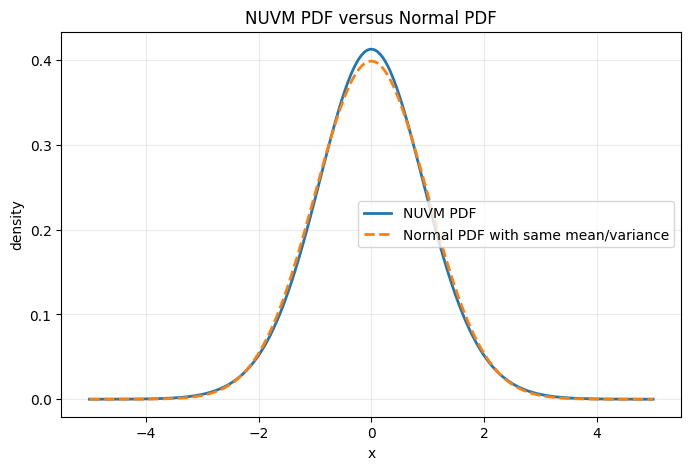

In [18]:
grid = np.linspace(-5, 5, 500)
nuvm_values = np.array([nuvm_pdf_closed(y, mu_value, sigma_value, a_value) for y in grid])
normal_values = np.exp(-(grid - mu_value)**2 / (2 * sigma_value**2)) / (sigma_value * np.sqrt(2 * np.pi))

plt.figure(figsize=(8, 5))
plt.plot(grid, nuvm_values, label='NUVM PDF', linewidth=2)
plt.plot(grid, normal_values, '--', label='Normal PDF with same mean/variance', linewidth=2)
plt.xlabel('x')
plt.ylabel('density')
plt.title('NUVM PDF versus Normal PDF')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 16. Sixth Central Moment

For a normal random variable with conditional variance $V$,

$$E[(X-\mu)^6\mid V]=15V^3.$$

Therefore,

$$E[(X-\mu)^6]=15E[V^3]=15\int_L^U v^3 g(v)\,dv.$$

In [19]:
moment6_conditional = 15 * v**3
moment6_integral = sp.Integral(moment6_conditional * g_v, (v, L, U))
moment6 = sp.factor(sp.simplify(sp.integrate(moment6_conditional * g_v, (v, L, U))))
standardized_moment6 = sp.factor(sp.simplify(moment6 / VarX**3))

display(sp.Eq(sp.Symbol('E_central_6_given_V'), moment6_conditional))
display(sp.Eq(sp.Symbol('E_central_6'), moment6_integral))
display(sp.Eq(sp.Symbol('E_central_6'), moment6))
display(sp.Eq(sp.Symbol('standardized_moment_6'), standardized_moment6))

                          3
E_central_6_given_V = 15⋅v 

               2                  
              σ ⋅(a + 1)          
                  ⌠               
                  ⎮          3    
                  ⎮      15⋅v     
E_central_6 =     ⎮      ────── dv
                  ⎮           2   
                  ⎮      2⋅a⋅σ    
                  ⌡               
               2                  
              σ ⋅(1 - a)          

                  6 ⎛ 2    ⎞
E_central_6 = 15⋅σ ⋅⎝a  + 1⎠

                          ⎛ 2    ⎞
standardizedₘₒₘₑₙₜ ₆ = 15⋅⎝a  + 1⎠

## 17. Eighth Central Moment

For a normal random variable with conditional variance $V$,

$$E[(X-\mu)^8\mid V]=105V^4.$$

Therefore,

$$E[(X-\mu)^8]=105E[V^4]=105\int_L^U v^4 g(v)\,dv.$$

In [20]:
moment8_conditional = 105 * v**4
moment8_integral = sp.Integral(moment8_conditional * g_v, (v, L, U))
moment8 = sp.factor(sp.simplify(sp.integrate(moment8_conditional * g_v, (v, L, U))))
standardized_moment8 = sp.factor(sp.simplify(moment8 / VarX**4))

display(sp.Eq(sp.Symbol('E_central_8_given_V'), moment8_conditional))
display(sp.Eq(sp.Symbol('E_central_8'), moment8_integral))
display(sp.Eq(sp.Symbol('E_central_8'), moment8))
display(sp.Eq(sp.Symbol('standardized_moment_8'), standardized_moment8))

                           4
E_central_8_given_V = 105⋅v 

               2                  
              σ ⋅(a + 1)          
                  ⌠               
                  ⎮           4   
                  ⎮      105⋅v    
E_central_8 =     ⎮      ────── dv
                  ⎮           2   
                  ⎮      2⋅a⋅σ    
                  ⌡               
               2                  
              σ ⋅(1 - a)          

                  8 ⎛ 4       2    ⎞
E_central_8 = 21⋅σ ⋅⎝a  + 10⋅a  + 5⎠

                          ⎛ 4       2    ⎞
standardizedₘₒₘₑₙₜ ₈ = 21⋅⎝a  + 10⋅a  + 5⎠

## 18. Tail Probability Study

For $\mu=0$ and $\sigma=1$, compare

$$P(|X|>c), \qquad c\in\{2,3,4\},$$

for the standard normal distribution and NUVM distributions with $a=0.2,0.5,0.8$.

For NUVM,

$$P(|X|>c)=\int_L^U 2\left[1-\Phi\left(\frac{c}{\sqrt v}\right)\right]g(v)\,dv.$$

In [21]:
import pandas as pd
from scipy.stats import norm

def nuvm_two_sided_tail(c_value, a_value, sigma_value=1.0):
    L_value = (1 - a_value) * sigma_value**2
    U_value = (1 + a_value) * sigma_value**2
    g_value = 1 / (U_value - L_value)

    def tail_integrand(v_value):
        return 2 * norm.sf(c_value / np.sqrt(v_value)) * g_value

    value, error = quad(tail_integrand, L_value, U_value, epsabs=1e-12, epsrel=1e-12)
    return value

thresholds = [2, 3, 4]
a_values = [0.2, 0.5, 0.8]

tail_rows = []
for c_value in thresholds:
    row = {
        'Threshold c': c_value,
        'Normal': 2 * norm.sf(c_value),
    }
    for a_value in a_values:
        row[f'NUVM(a={a_value})'] = nuvm_two_sided_tail(c_value, a_value)
    tail_rows.append(row)

tail_table = pd.DataFrame(tail_rows)
display(tail_table)

tail_ratio_table = tail_table.copy()
for column in tail_ratio_table.columns:
    if column.startswith('NUVM'):
        tail_ratio_table[column] = tail_ratio_table[column] / tail_ratio_table['Normal']

tail_ratio_table = tail_ratio_table.drop(columns=['Normal'])
display(tail_ratio_table.rename(columns={col: f'{col} / Normal' for col in tail_ratio_table.columns if col.startswith('NUVM')}))

,Threshold c,Normal,NUVM(a=0.2),NUVM(a=0.5),NUVM(a=0.8)
0,2,0.045500,0.045868,0.048028,0.052644
1,3,0.002700,0.002963,0.004254,0.006338
2,4,0.000063,0.000087,0.000218,0.000491


,Threshold c,NUVM(a=0.2) / Normal,NUVM(a=0.5) / Normal,NUVM(a=0.8) / Normal
0,2,1.008079,1.055547,1.156997
1,3,1.097418,1.575757,2.347713
2,4,1.370345,3.442038,7.747465


The second table reports tail probability ratios relative to the normal model. Values above one show how much more tail mass NUVM assigns at the same threshold.

## 19. Manuscript-Ready Summary

The notebook has shown:

$$E[X]=\mu,$$

$$\operatorname{Var}(X)=\sigma^2,$$

$$E[(X-\mu)^4]=3\sigma^4\left(1+\frac{a^2}{3}\right),$$

$$\kappa=3+a^2,$$

$$\gamma_2=a^2.$$

$$E[(X-\mu)^6]=15\sigma^6(a^2+1),$$

$$E[(X-\mu)^8]=21\sigma^8(3a^4+10a^2+5).$$

Thus the NUVM distribution preserves mean $\mu$ and variance $\sigma^2$, while adding excess kurtosis controlled by $a$.